<h1 style="text-align:center;">TREĆI PROJEKAT</h1>

<h2 style="font-style:italic; font-weight:bold; text-align: center;">
    Analiza sentimenata recenzija filmova sa platforme IMDB primenom neuronskih mreža
</h2>

## 1. Uvod
Cilj ovog projekta je primena veštačkih neuronskih mreža za analizu sentimenata tekstualnih podataka. Analiza sentimenata predstavlja zadatak klasifikacije teksta gde je potrebno utvrditi da li tekst ima pozitivan ili negativan sentiment.

Za potrebe ovog rada korišćene je IMDB dataset kojib sadrži 50000 filmskih recenzija. Svaka recenzija je označena kao pozitivna ili negativna.

Dataset je preuzet sa Kaggle platforme: [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

Za imeplemntaciju modela korišćene su sledeće biblioteke:
- Python
- Pandas
- Scikit-learn
- TensorFlow / Keras
- Matplotlib i Seaborn

## 2. Učitavanje biblioteka

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

## 3. Učitavanje skupa podataka
Dataset sadrži 50000 filmskih recenzija sa oznakom sentimenta. Kolone dataset-a su:
- review - tejst recenzije
- sentiment - oznaka sentimenta (positive ili negative)

In [4]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.shape

(50000, 2)

## 4. Deskriptivna analiza
U ovom delu analiyiramo osovne karaktersitike dataset-a:
- distribuciju sentimenta
- nedostajuće vrednosti

### Provera nedostajućih vrednosti

In [6]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

### Distribucija sentimenta 

In [8]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

### Vizuelizacija

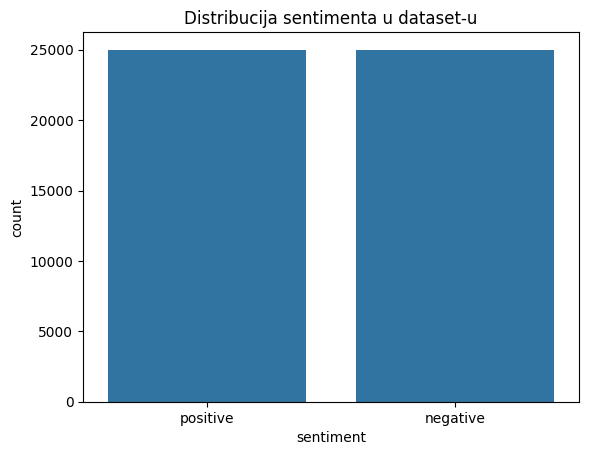

In [9]:
sns.countplot(x='sentiment', data = df)
plt.title("Distribucija sentimenta u dataset-u")
plt.show()

Iz grafika se može videti da dataset sadrži približno jednak broj poyitivnih i negativnih recenzija, što je pogodno za treniranje modela.

## 5. Priprema podataka
Tekstualni podaci moraju biti pretvoreni u numerički oblik kako bi neuronska mreža mogal da ih obradi.

Koraci pripreme podataka:
- Pretvaranje sentimenata u numeričke vrednosti
- Tokenizaciju teksta
- Pretvaranje teksta u sekvence brojeva
- Padding sekvenci

### Kodiranje sentimenata

In [10]:
encoder = LabelEncoder()
df['sentiment'] = encoder.fit_transform(df['sentiment'])
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


### Tokenizacija teksta
Tokenizacija predstavlja proces pretvranja teksta u niz tokena (reči) koji se zatim mapiraju na numeričke vrednosti.

In [11]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['review'])
X = tokenizer.texts_to_sequences(df['review'])

### Padding sekvenci

In [12]:
X = pad_sequences(X, maxlen = 200)

In [13]:
#target promenljiva
y = df['sentiment']

### Podela na trening i test skup

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 6. Kreiranje neuronske mreže
Za analizu sentimenata koristićemo LSTM (Long Short - Term Memory) neuronsku mrežu koja je pogodna za obradu sekvencijalnih podataka kao što je teskt.

In [17]:
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=128, input_length = 200))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))